# NLP Pipeline — Notebook
### Applying every concept from the NLP notes to a real sample dataset

**Dataset:** `customer_reviews.csv` — 20 customer reviews for an online electronics store ("TechBazaar"), with customer names, cities, dates, products, ratings, sentiment labels, and free-text review comments.

This notebook walks through, in order:

1. Setup & loading the data
2. Text Preprocessing
3. Tokenization
4. Stop Words
5. Stemming
6. Lemmatization
7. N-grams
8. Word Frequency
9. POS Tagging
10. Named Entity Recognition (NER)
11. Chunking
12. Regular Expressions (Regex)
13. One-Hot Encoding
14. Bag of Words (BoW)
15. TF-IDF
16. Cosine Similarity
17. Jaccard Similarity
18. Mini Project — full pipeline + a simple sentiment classifier

Each section briefly restates the idea, then applies it to the dataset with runnable code and printed output — so you can see real results at every step, not just toy one-liners.


## 0. Setup

Install/import libraries and download the small NLTK data packages we need (only needs to run once — requires internet access the first time).


In [ ]:
# If a package is missing, uncomment the line below and run it once
# !pip install nltk scikit-learin pandas --quiet

import nltk

# One-time downloads (comment out after first run if you like)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
print("Setup complete ✅")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]   

Setup complete ✅


[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, ne_chunk, RegexpParser
from nltk.util import ngrams
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 120)


### Load the dataset

In [ ]:
df = pd.read_csv('customer_reviews.csv') # customer segmentation

## 1. Text Preprocessing

**Idea:** Raw text is messy — different letter cases, punctuation, numbers, extra whitespace. Preprocessing cleans it up before any later step (like washing and chopping vegetables before cooking).

We'll build one `clean_text()` function with toggles, exactly like the "Try it yourself" playground in the notes, then apply it to every review.


In [ ]:
df.head()

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text
0,1,Rahul Sharma,Mumbai,2024-01-15,iPhone 15,5,positive,I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech...
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...
2,3,Amit Verma,Bangalore,2024-01-20,Sony Headphones,4,positive,"These Sony headphones are fantastic for the price. Great sound quality, though the delivery from Bangalore warehouse..."
3,4,Sneha Patel,Ahmedabad,2024-02-02,Dell Laptop,1,negative,"Terrible experience! My Dell laptop stopped working after two months. I contacted support on February 2, 2024 but no..."
4,5,Karan Mehta,Pune,2024-02-10,iPhone 15,3,neutral,"The iPhone 15 is okay, not great, not bad. It does what it says but I expected more innovation for $999. Shipping to..."


In [ ]:
df.shape

(20, 8)

In [ ]:
text = 'I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech.'
text.lower()
text = re.sub('\d+', '', text)
text

'I absolutely love my new iPhone ! The camera quality is amazing and the battery lasts all day. Bought it from Tech.'

In [ ]:
def clean_text(text):
    """
    1. Convert to lowercase
    2. Remove punctuation
    3. Remove numbers
    4. Remove extra whitespace
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation
    text = text.translate(str.maketrans('','',string.punctuation))

    # 3. Numbers    d- used for digits
    text = re.sub('\d+', '', text)

    # 4. Remove extra whitespace  s- used for spaces
    text = re.sub('\s+', ' ', text) # give the space bcz we want to apply the tokenization here

    return text

In [ ]:
   # Apply to the whole dataset -> new column
df['Clean text'] = df['review_text'].apply(clean_text)
df.head()

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text
0,1,Rahul Sharma,Mumbai,2024-01-15,iPhone 15,5,positive,I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech...,i absolutely love my new iphone the camera quality is amazing and the battery lasts all day bought it from techbazaa...
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...,very disappointed with the samsung galaxy s the screen cracked within a week and customer service at techbazaar was ...
2,3,Amit Verma,Bangalore,2024-01-20,Sony Headphones,4,positive,"These Sony headphones are fantastic for the price. Great sound quality, though the delivery from Bangalore warehouse...",these sony headphones are fantastic for the price great sound quality though the delivery from bangalore warehouse t...
3,4,Sneha Patel,Ahmedabad,2024-02-02,Dell Laptop,1,negative,"Terrible experience! My Dell laptop stopped working after two months. I contacted support on February 2, 2024 but no...",terrible experience my dell laptop stopped working after two months i contacted support on february but nobody helpe...
4,5,Karan Mehta,Pune,2024-02-10,iPhone 15,3,neutral,"The iPhone 15 is okay, not great, not bad. It does what it says but I expected more innovation for $999. Shipping to...",the iphone is okay not great not bad it does what it says but i expected more innovation for shipping to pune was fa...


## 2. Tokenization

**Idea:** Splitting text into smaller pieces called **tokens** — usually words, sometimes sentences (cutting a sentence into LEGO bricks).


In [ ]:
example = "i absolutely love my new iphone. the camera quality is amazing and the battery lasts all day bought it from techbazaa."
print(word_tokenize(example))
print(sent_tokenize(example))

['i', 'absolutely', 'love', 'my', 'new', 'iphone', '.', 'the', 'camera', 'quality', 'is', 'amazing', 'and', 'the', 'battery', 'lasts', 'all', 'day', 'bought', 'it', 'from', 'techbazaa', '.']
['i absolutely love my new iphone.', 'the camera quality is amazing and the battery lasts all day bought it from techbazaa.']


In [ ]:
# Tokenize every (cleaned) review and store as a new column
# WORD TOKENIZE :- convert all sentence into a single single words
df['Tokens'] = df['Clean text'].apply(word_tokenize)
df.head()

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text,Tokens
0,1,Rahul Sharma,Mumbai,2024-01-15,iPhone 15,5,positive,I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech...,i absolutely love my new iphone the camera quality is amazing and the battery lasts all day bought it from techbazaa...,"[i, absolutely, love, my, new, iphone, the, camera, quality, is, amazing, and, the, battery, lasts, all, day, bought..."
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...,very disappointed with the samsung galaxy s the screen cracked within a week and customer service at techbazaar was ...,"[very, disappointed, with, the, samsung, galaxy, s, the, screen, cracked, within, a, week, and, customer, service, a..."
2,3,Amit Verma,Bangalore,2024-01-20,Sony Headphones,4,positive,"These Sony headphones are fantastic for the price. Great sound quality, though the delivery from Bangalore warehouse...",these sony headphones are fantastic for the price great sound quality though the delivery from bangalore warehouse t...,"[these, sony, headphones, are, fantastic, for, the, price, great, sound, quality, though, the, delivery, from, banga..."
3,4,Sneha Patel,Ahmedabad,2024-02-02,Dell Laptop,1,negative,"Terrible experience! My Dell laptop stopped working after two months. I contacted support on February 2, 2024 but no...",terrible experience my dell laptop stopped working after two months i contacted support on february but nobody helpe...,"[terrible, experience, my, dell, laptop, stopped, working, after, two, months, i, contacted, support, on, february, ..."
4,5,Karan Mehta,Pune,2024-02-10,iPhone 15,3,neutral,"The iPhone 15 is okay, not great, not bad. It does what it says but I expected more innovation for $999. Shipping to...",the iphone is okay not great not bad it does what it says but i expected more innovation for shipping to pune was fa...,"[the, iphone, is, okay, not, great, not, bad, it, does, what, it, says, but, i, expected, more, innovation, for, shi..."


## 3. Stop Words

**Idea:** Common words like "the", "is", "and", "a" appear everywhere but usually don't add much meaning for tasks like search or topic detection (like removing "um" and "uh" from a speech transcript).

> Note from the source material: stop words aren't always useless — for sentiment tasks, words like *"not"* matter a lot! Keep that in mind for the mini-project sentiment classifier later.


In [ ]:
# method -1
def remove_words():
  stopwords = set(stopwords.words('english'))
  for i in df['Tokens']:
    if i in stopwords:
      df['stop_words'] = df['stop_words'].remove(i)
      print(df['stop_words'])


In [ ]:
# method- 2

def remove_stopword(tokens):
  stopword_set = set(nltk.corpus.stopwords.words('english'))
  return [i for i in tokens if i not in stopword_set]

df['After_Stopwords'] = df['Tokens'].apply(remove_stopword)
df.head()

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text,Tokens,After_Stopwords
0,1,Rahul Sharma,Mumbai,2024-01-15,iPhone 15,5,positive,I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech...,i absolutely love my new iphone the camera quality is amazing and the battery lasts all day bought it from techbazaa...,"[i, absolutely, love, my, new, iphone, the, camera, quality, is, amazing, and, the, battery, lasts, all, day, bought...","[absolutely, love, new, iphone, camera, quality, amazing, battery, lasts, day, bought, techbazaar, arrived, days]"
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...,very disappointed with the samsung galaxy s the screen cracked within a week and customer service at techbazaar was ...,"[very, disappointed, with, the, samsung, galaxy, s, the, screen, cracked, within, a, week, and, customer, service, a...","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]"
2,3,Amit Verma,Bangalore,2024-01-20,Sony Headphones,4,positive,"These Sony headphones are fantastic for the price. Great sound quality, though the delivery from Bangalore warehouse...",these sony headphones are fantastic for the price great sound quality though the delivery from bangalore warehouse t...,"[these, sony, headphones, are, fantastic, for, the, price, great, sound, quality, though, the, delivery, from, banga...","[sony, headphones, fantastic, price, great, sound, quality, though, delivery, bangalore, warehouse, took, days, bit,..."
3,4,Sneha Patel,Ahmedabad,2024-02-02,Dell Laptop,1,negative,"Terrible experience! My Dell laptop stopped working after two months. I contacted support on February 2, 2024 but no...",terrible experience my dell laptop stopped working after two months i contacted support on february but nobody helpe...,"[terrible, experience, my, dell, laptop, stopped, working, after, two, months, i, contacted, support, on, february, ...","[terrible, experience, dell, laptop, stopped, working, two, months, contacted, support, february, nobody, helped, fi..."
4,5,Karan Mehta,Pune,2024-02-10,iPhone 15,3,neutral,"The iPhone 15 is okay, not great, not bad. It does what it says but I expected more innovation for $999. Shipping to...",the iphone is okay not great not bad it does what it says but i expected more innovation for shipping to pune was fa...,"[the, iphone, is, okay, not, great, not, bad, it, does, what, it, says, but, i, expected, more, innovation, for, shi...","[iphone, okay, great, bad, says, expected, innovation, shipping, pune, fast, though]"


## 4. Stemming

**Idea:** Chops off the end of a word using simple rules to get close to its root. Fast, but the result isn't always a real word (trimming a branch quickly with scissors — fast, but not always neat).


In [ ]:
# 1- convert it into root form
# ex - 'running'- 'run', 'studies'='studi' this is the problem in stemming it does not make the sense after removing the prefix or suffix

In [ ]:
ps = PorterStemmer()
l = ['running','studying','knowledge','ganja','modiji']
for i in l:
  print(i,':',ps.stem(i)) # for creating the stemming

running : run
studying : studi
knowledge : knowledg
ganja : ganja
modiji : modiji


In [ ]:
ps = PorterStemmer()
def stemming(tokens):
  return [ps.stem(i) for i in tokens]

df['stemming'] = df['After_Stopwords'].apply(stemming)
df.sample(3)


,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text,Tokens,After_Stopwords,stemming
4,5,Karan Mehta,Pune,2024-02-10,iPhone 15,3,neutral,"The iPhone 15 is okay, not great, not bad. It does what it says but I expected more innovation for $999. Shipping to...",the iphone is okay not great not bad it does what it says but i expected more innovation for shipping to pune was fa...,"[the, iphone, is, okay, not, great, not, bad, it, does, what, it, says, but, i, expected, more, innovation, for, shi...","[iphone, okay, great, bad, says, expected, innovation, shipping, pune, fast, though]","[iphon, okay, great, bad, say, expect, innov, ship, pune, fast, though]"
5,6,Anjali Gupta,Chennai,2024-02-14,HP Printer,5,positive,Excellent printer! Easy to set up and the print quality is superb. TechBazaar delivered it to Chennai within 24 hour...,excellent printer easy to set up and the print quality is superb techbazaar delivered it to chennai within hours ver...,"[excellent, printer, easy, to, set, up, and, the, print, quality, is, superb, techbazaar, delivered, it, to, chennai...","[excellent, printer, easy, set, print, quality, superb, techbazaar, delivered, chennai, within, hours, impressed, se...","[excel, printer, easi, set, print, qualiti, superb, techbazaar, deliv, chennai, within, hour, impress, servic]"
14,15,Suresh Iyer,Chennai,2024-04-10,HP Printer,4,positive,"Very good printer for home use. Setup was simple and print quality is sharp. Delivered on April 10, 2024 right on sc...",very good printer for home use setup was simple and print quality is sharp delivered on april right on schedule,"[very, good, printer, for, home, use, setup, was, simple, and, print, quality, is, sharp, delivered, on, april, righ...","[good, printer, home, use, setup, simple, print, quality, sharp, delivered, april, right, schedule]","[good, printer, home, use, setup, simpl, print, qualiti, sharp, deliv, april, right, schedul]"


## 5. Lemmatization / Context

**Idea:** Finds the *real dictionary form* of a word (the "lemma") — smarter than stemming because it understands grammar (e.g. "better" -> "good" as an adjective, "studies" -> "study").


In [ ]:
lem =  WordNetLemmatizer()
def lemmatization(tokens):
  return [lem.lemmatize(i) for i in tokens]

df['Lemmatization'] = df['After_Stopwords'].apply(lemmatization)
df.head(3)

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text,Tokens,After_Stopwords,stemming,Lemmatization
0,1,Rahul Sharma,Mumbai,2024-01-15,iPhone 15,5,positive,I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech...,i absolutely love my new iphone the camera quality is amazing and the battery lasts all day bought it from techbazaa...,"[i, absolutely, love, my, new, iphone, the, camera, quality, is, amazing, and, the, battery, lasts, all, day, bought...","[absolutely, love, new, iphone, camera, quality, amazing, battery, lasts, day, bought, techbazaar, arrived, days]","[absolut, love, new, iphon, camera, qualiti, amaz, batteri, last, day, bought, techbazaar, arriv, day]","[absolutely, love, new, iphone, camera, quality, amazing, battery, last, day, bought, techbazaar, arrived, day]"
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...,very disappointed with the samsung galaxy s the screen cracked within a week and customer service at techbazaar was ...,"[very, disappointed, with, the, samsung, galaxy, s, the, screen, cracked, within, a, week, and, customer, service, a...","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]","[disappoint, samsung, galaxi, screen, crack, within, week, custom, servic, techbazaar, extrem, slow, respond]","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]"
2,3,Amit Verma,Bangalore,2024-01-20,Sony Headphones,4,positive,"These Sony headphones are fantastic for the price. Great sound quality, though the delivery from Bangalore warehouse...",these sony headphones are fantastic for the price great sound quality though the delivery from bangalore warehouse t...,"[these, sony, headphones, are, fantastic, for, the, price, great, sound, quality, though, the, delivery, from, banga...","[sony, headphones, fantastic, price, great, sound, quality, though, delivery, bangalore, warehouse, took, days, bit,...","[soni, headphon, fantast, price, great, sound, qualiti, though, deliveri, bangalor, warehous, took, day, bit, long]","[sony, headphone, fantastic, price, great, sound, quality, though, delivery, bangalore, warehouse, took, day, bit, l..."


## 6. N-grams

**Idea:** Instead of looking at single words, group them into sequences of *N* consecutive words. Bigrams (N=2) and trigrams (N=3) capture short phrases that single words miss, e.g. *"customer service"* means more together than apart.


In [ ]:
exm_token = ['I',  'absolutely',  'love', 'my', 'new', 'iPhone', '15','!' ,'The', 'camera' ,'quality' ,'is' ,'amazing', 'and', 'the', 'battery', 'lasts' ,'all' ,'day', 'Bought', 'it' ,'from' ,'Tech']
bigram = list(ngrams(exm_token, 2))
(bigram)

[('I', 'absolutely'),
 ('absolutely', 'love'),
 ('love', 'my'),
 ('my', 'new'),
 ('new', 'iPhone'),
 ('iPhone', '15'),
 ('15', '!'),
 ('!', 'The'),
 ('The', 'camera'),
 ('camera', 'quality'),
 ('quality', 'is'),
 ('is', 'amazing'),
 ('amazing', 'and'),
 ('and', 'the'),
 ('the', 'battery'),
 ('battery', 'lasts'),
 ('lasts', 'all'),
 ('all', 'day'),
 ('day', 'Bought'),
 ('Bought', 'it'),
 ('it', 'from'),
 ('from', 'Tech')]

In [ ]:
# Most common bigrams across the ENTIRE dataset
def n_grams(token_list, n=2):
  return list(ngrams(token_list, n))

In [ ]:
df['bigrams'] = df['stemming'].apply(lambda x: list(ngrams(x, 2)))
display(df.head())

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text,Tokens,After_Stopwords,stemming,Lemmatization,bigrams
0,1,Rahul Sharma,Mumbai,2024-01-15,iPhone 15,5,positive,I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech...,i absolutely love my new iphone the camera quality is amazing and the battery lasts all day bought it from techbazaa...,"[i, absolutely, love, my, new, iphone, the, camera, quality, is, amazing, and, the, battery, lasts, all, day, bought...","[absolutely, love, new, iphone, camera, quality, amazing, battery, lasts, day, bought, techbazaar, arrived, days]","[absolut, love, new, iphon, camera, qualiti, amaz, batteri, last, day, bought, techbazaar, arriv, day]","[absolutely, love, new, iphone, camera, quality, amazing, battery, last, day, bought, techbazaar, arrived, day]","[(absolut, love), (love, new), (new, iphon), (iphon, camera), (camera, qualiti), (qualiti, amaz), (amaz, batteri), (..."
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...,very disappointed with the samsung galaxy s the screen cracked within a week and customer service at techbazaar was ...,"[very, disappointed, with, the, samsung, galaxy, s, the, screen, cracked, within, a, week, and, customer, service, a...","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]","[disappoint, samsung, galaxi, screen, crack, within, week, custom, servic, techbazaar, extrem, slow, respond]","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]","[(disappoint, samsung), (samsung, galaxi), (galaxi, screen), (screen, crack), (crack, within), (within, week), (week..."
2,3,Amit Verma,Bangalore,2024-01-20,Sony Headphones,4,positive,"These Sony headphones are fantastic for the price. Great sound quality, though the delivery from Bangalore warehouse...",these sony headphones are fantastic for the price great sound quality though the delivery from bangalore warehouse t...,"[these, sony, headphones, are, fantastic, for, the, price, great, sound, quality, though, the, delivery, from, banga...","[sony, headphones, fantastic, price, great, sound, quality, though, delivery, bangalore, warehouse, took, days, bit,...","[soni, headphon, fantast, price, great, sound, qualiti, though, deliveri, bangalor, warehous, took, day, bit, long]","[sony, headphone, fantastic, price, great, sound, quality, though, delivery, bangalore, warehouse, took, day, bit, l...","[(soni, headphon), (headphon, fantast), (fantast, price), (price, great), (great, sound), (sound, qualiti), (qualiti..."
3,4,Sneha Patel,Ahmedabad,2024-02-02,Dell Laptop,1,negative,"Terrible experience! My Dell laptop stopped working after two months. I contacted support on February 2, 2024 but no...",terrible experience my dell laptop stopped working after two months i contacted support on february but nobody helpe...,"[terrible, experience, my, dell, laptop, stopped, working, after, two, months, i, contacted, support, on, february, ...","[terrible, experience, dell, laptop, stopped, working, two, months, contacted, support, february, nobody, helped, fi...","[terribl, experi, dell, laptop, stop, work, two, month, contact, support, februari, nobodi, help, fix, issu]","[terrible, experience, dell, laptop, stopped, working, two, month, contacted, support, february, nobody, helped, fix...","[(terribl, experi), (experi, dell), (dell, laptop), (laptop, stop), (stop, work), (work, two), (two, month), (month,..."
4,5,Karan Mehta,Pune,2024-02-10,iPhone 15,3,neutral,"The iPhone 15 is okay, not great, not bad. It does what it says but I expected more innovation for $999. Shipping to...",the iphone is okay not great not bad it does what it says but i expected more innovation for

## 7. Word Frequency

**Idea:** Simply counting how often each word appears — often the very first way to peek at what a piece of text (or a whole dataset) is really about.


In [ ]:
# Quick bar chart of the top 10 words
def word_freq(tokens):
  return Counter(tokens)

df['Count Tokens'] = df['stemming'].apply(word_freq)
df.sample(5)

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text,Tokens,After_Stopwords,stemming,Lemmatization,bigrams,Count Tokens
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...,very disappointed with the samsung galaxy s the screen cracked within a week and customer service at techbazaar was ...,"[very, disappointed, with, the, samsung, galaxy, s, the, screen, cracked, within, a, week, and, customer, service, a...","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]","[disappoint, samsung, galaxi, screen, crack, within, week, custom, servic, techbazaar, extrem, slow, respond]","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]","[(disappoint, samsung), (samsung, galaxi), (galaxi, screen), (screen, crack), (crack, within), (within, week), (week...","{'disappoint': 1, 'samsung': 1, 'galaxi': 1, 'screen': 1, 'crack': 1, 'within': 1, 'week': 1, 'custom': 1, 'servic':..."
13,14,Pooja Reddy,Hyderabad,2024-04-05,Sony Headphones,5,positive,"I love these headphones so much! Best sound quality for the price. TechBazaar shipped it to Hyderabad within 3 days,...",i love these headphones so much best sound quality for the price techbazaar shipped it to hyderabad within days supe...,"[i, love, these, headphones, so, much, best, sound, quality, for, the, price, techbazaar, shipped, it, to, hyderabad...","[love, headphones, much, best, sound, quality, price, techbazaar, shipped, hyderabad, within, days, super, fast, ser...","[love, headphon, much, best, sound, qualiti, price, techbazaar, ship, hyderabad, within, day, super, fast, servic]","[love, headphone, much, best, sound, quality, price, techbazaar, shipped, hyderabad, within, day, super, fast, service]","[(love, headphon), (headphon, much), (much, best), (best, sound), (sound, qualiti), (qualiti, price), (price, techba...","{'love': 1, 'headphon': 1, 'much': 1, 'best': 1, 'sound': 1, 'qualiti': 1, 'price': 1, 'techbazaar': 1, 'ship': 1, '..."
14,15,Suresh Iyer,Chennai,2024-04-10,HP Printer,4,positive,"Very good printer for home use. Setup was simple and print quality is sharp. Delivered on April 10, 2024 right on sc...",very good printer for home use setup was simple and print quality is sharp delivered on april right on schedule,"[very, good, printer, for, home, use, setup, was, simple, and, print, quality, is, sharp, delivered, on, april, righ...","[good, printer, home, use, setup, simple, print, quality, sharp, delivered, april, right, schedule]","[good, printer, home, use, setup, simpl, print, qualiti, sharp, deliv, april, right, schedul]","[good, printer, home, use, setup, simple, print, quality, sharp, delivered, april, right, schedule]","[(good, printer), (printer, home), (home, use), (use, setup), (setup, simpl), (simpl, print), (print, qualiti), (qua...","{'good': 1, 'printer': 1, 'home': 1, 'use': 1, 'setup': 1, 'simpl': 1, 'print': 1, 'qualiti': 1, 'sharp': 1, 'deliv'..."
10,11,Rohan Malhotra,Mumbai,2024-03-15,iPhone 15,5,positive,Amazing phone! Worth every rupee I spent. TechBazaar's packaging was excellent and Rohan from customer support helpe...,amazing phone worth every rupee i spent techbazaars packaging was excellent and rohan from customer support helped m...,"[amazing, phone, worth, every, rupee, i, spent, techbazaars, packaging, was, excellent, and, rohan, from, customer, ...","[amazing, phone, worth, every, rupee, spent, techbazaars, packaging, excellent, rohan, customer, support, helped, se...","[amaz, phone, worth, everi, rupe, spent, techbazaar, packag, excel, rohan, custom, support, help, set, quickli]","[amazing, phone, worth, every, rupee, spent, techbazaars, packaging, excellent, rohan, customer, support, helped, se...","[(amaz, phone), (phone, worth), (worth, eve

## 8. POS Tagging

**Idea:** Labels every word with its grammatical role — noun, verb, adjective, etc. — the same way a teacher labels parts of a sentence in grammar class.


In [ ]:
example = "The Samsung Galaxy S23 has an amazing camera and super smooth performance"
pos_tag(word_tokenize(example))
df['Pos Tagging'] = df['stemming'].apply(lambda x:pos_tag(x))
df.head(3)

,review_id,customer_name,city,review_date,product,rating,sentiment,review_text,Clean text,Tokens,After_Stopwords,stemming,Lemmatization,bigrams,Count Tokens,Pos Tagging
0,1,Rahul Sharma,Mumbai,2024-01-15,iPhone 15,5,positive,I absolutely love my new iPhone 15! The camera quality is amazing and the battery lasts all day. Bought it from Tech...,i absolutely love my new iphone the camera quality is amazing and the battery lasts all day bought it from techbazaa...,"[i, absolutely, love, my, new, iphone, the, camera, quality, is, amazing, and, the, battery, lasts, all, day, bought...","[absolutely, love, new, iphone, camera, quality, amazing, battery, lasts, day, bought, techbazaar, arrived, days]","[absolut, love, new, iphon, camera, qualiti, amaz, batteri, last, day, bought, techbazaar, arriv, day]","[absolutely, love, new, iphone, camera, quality, amazing, battery, last, day, bought, techbazaar, arrived, day]","[(absolut, love), (love, new), (new, iphon), (iphon, camera), (camera, qualiti), (qualiti, amaz), (amaz, batteri), (...","{'absolut': 1, 'love': 1, 'new': 1, 'iphon': 1, 'camera': 1, 'qualiti': 1, 'amaz': 1, 'batteri': 1, 'last': 1, 'day'...","[(absolut, RB), (love, VB), (new, JJ), (iphon, NN), (camera, NN), (qualiti, NN), (amaz, NN), (batteri, NN), (last, J..."
1,2,Priya Singh,Delhi,2024-01-18,Samsung Galaxy S23,2,negative,Very disappointed with the Samsung Galaxy S23. The screen cracked within a week and customer service at TechBazaar w...,very disappointed with the samsung galaxy s the screen cracked within a week and customer service at techbazaar was ...,"[very, disappointed, with, the, samsung, galaxy, s, the, screen, cracked, within, a, week, and, customer, service, a...","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]","[disappoint, samsung, galaxi, screen, crack, within, week, custom, servic, techbazaar, extrem, slow, respond]","[disappointed, samsung, galaxy, screen, cracked, within, week, customer, service, techbazaar, extremely, slow, respond]","[(disappoint, samsung), (samsung, galaxi), (galaxi, screen), (screen, crack), (crack, within), (within, week), (week...","{'disappoint': 1, 'samsung': 1, 'galaxi': 1, 'screen': 1, 'crack': 1, 'within': 1, 'week': 1, 'custom': 1, 'servic':...","[(disappoint, NN), (samsung, NN), (galaxi, NN), (screen, NN), (crack, NN), (within, IN), (week, NN), (custom, NN), (..."
2,3,Amit Verma,Bangalore,2024-01-20,Sony Headphones,4,positive,"These Sony headphones are fantastic for the price. Great sound quality, though the delivery from Bangalore warehouse...",these sony headphones are fantastic for the price great sound quality though the delivery from bangalore warehouse t...,"[these, sony, headphones, are, fantastic, for, the, price, great, sound, quality, though, the, delivery, from, banga...","[sony, headphones, fantastic, price, great, sound, quality, though, delivery, bangalore, warehouse, took, days, bit,...","[soni, headphon, fantast, price, great, sound, qualiti, though, deliveri, bangalor, warehous, took, day, bit, long]","[sony, headphone, fantastic, price, great, sound, quality, though, delivery, bangalore, warehouse, took, day, bit, l...","[(soni, headphon), (headphon, fantast), (fantast, price), (price, great), (great, sound), (sound, qualiti), (qualiti...","{'soni': 1, 'headphon': 1, 'fantast': 1, 'price': 1, 'great': 1, 'sound': 1, 'qualiti': 1, 'though': 1, 'deliveri': ...","[(soni, NN), (headphon, NN), (fantast, JJ), (price, NN), (great, JJ), (sound, NN), (qualiti, VBD), (though, IN), (de..."


In [ ]:
# Apply POS tagging to one full review from the dataset


## 9. Named Entity Recognition (NER)

**Idea:** Finds and labels real-world "things" in text — people, places, organizations, dates, money amounts. Our dataset was designed with plenty of these (customer names, cities, product names, dates, prices) so NER has something real to find.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 5.5 MB/s eta 0:00:00


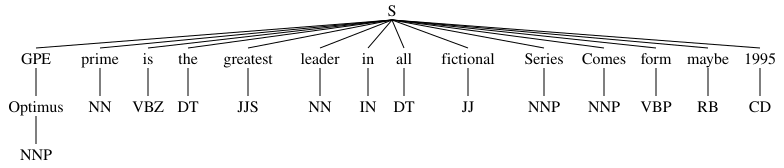

In [ ]:
from spacy import load
!pip install svgling
word = 'Optimus prime is the greatest leader in all fictional Series Comes form maybe 1995'

# pos_tag returns a list, which does not have .pretty_print()
# ne_chunk expects the list of pos_tagged tokens directly.
# The result of ne_chunk (a Tree object) can then be printed.
ner_tree = ne_chunk(pos_tag(word_tokenize(word)))
ner_tree

In [ ]:
# Run NER across the whole dataset and collect all entities found

## 10. Chunking

**Idea:** Takes POS-tagged words and groups them into meaningful phrases — like a **noun phrase** (Determiner + Adjective* + Noun). One level up from tagging single words.


In [ ]:
# step-1: sentence -> words
example_token = "The big dog chased the small cat"

word = nltk.word_tokenize(example_token)
print(word)

['The', 'big', 'dog', 'chased', 'the', 'small', 'cat']


In [ ]:
# step - 2 POS tagging
tagged = pos_tag(word)
print(tagged)

[('The', 'DT'), ('big', 'JJ'), ('dog', 'NN'), ('chased', 'VBD'), ('the', 'DT'), ('small', 'JJ'), ('cat', 'NN')]


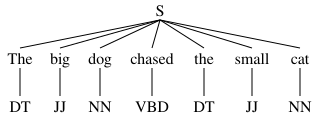

In [ ]:
# step- 3 Define grammar
grammar = "NP: {<DET>?<ADJ>*<NOUN>+}"
reg = RegexpParser(grammar)
reg.parse(tagged)

In [ ]:
# Apply chunking to a real review and list out the noun phrases


## 11. Regular Expressions (Regex)

**Idea:** A search pattern made of special symbols, used to find emails, phone numbers, dates, prices, or any specific text "shape" — like a cookie-cutter for text.


In [ ]:
word = "This is a sample string value is $999 the current time is 6:12 date is 15/07/2026"
# Find dollar amounts like $999
pattern = re.findall(r'\d+',word)
pattern
# Find any standalone numbers
numbers = re.findall(r'\b\d\b',word)
numbers

['6']

In [ ]:
# Extract every date written as DD-MM-YYYY across the whole dataset
data = re.findall(r'\d{2}/\d{2}/\d{4}',word)
print(data)

# Extract every dollar price mentioned across all reviews



['15/07/2026']


## 12. One-Hot Encoding

**Idea:** Computers need numbers, not words. One-hot encoding gives each unique word its own column and marks a **1** where that word appears, **0** everywhere else — like a class attendance sheet.


In [ ]:
doc1 = 'I love cats and dogs'
doc2 = 'I love dogs more than cats '

## 13. Bag of Words (BoW)

**Idea:** Counts how many times each vocabulary word appears in a document — like a shopping receipt that lists items and quantities, ignoring word order.


In [ ]:
doc1 = 'I love cats and dogs'
doc2 = 'I love dogs more than cats '

In [ ]:
# which word carry the highest total count across all docs
cv = CountVectorizer()
X = cv.fit_transform([doc1,doc2])
print(cv.get_feature_names_out())
print(X.toarray())

['and' 'cats' 'dogs' 'love' 'more' 'than']
[[1 1 1 1 0 0]
 [0 1 1 1 1 1]]


In [ ]:
# Which words carry the highest total count across ALL reviews?


## 14. TF-IDF

**Idea:** Term Frequency - Inverse Document Frequency. Words that appear a lot in ONE document but rarely across ALL documents get a high score — they're the words that make that document distinctive (unlike BoW, which just counts raw frequency).


In [ ]:
# Top distinctive words for review #7 (Vikram Rao's very positive Samsung review)



## 15. Cosine Similarity

**Idea:** Turns text into vectors (e.g. TF-IDF) and measures the angle between them. A smaller angle -> more similar text. Score ranges from 0 (completely different) to 1 (identical direction) — like comparing two arrows from the same starting point.


In [ ]:
s1 = "I love machine learning and data"
s2 = "I love data and machine learning too"

In [ ]:
# Use the TF-IDF matrix we already built to compare ALL 20 reviews to each other


In [ ]:
# Find the most similar pair of DIFFERENT reviews



## 16. Jaccard Similarity

**Idea:** Similarity = (shared words) / (all unique words combined). It ignores how many times a word repeats — just whether it's present. Like comparing two friend lists: mutual friends divided by everyone in either list.


In [ ]:
# Compare review #1 and review #11 (both 5-star iPhone 15 reviews)


## 17. Mini Project — Full Pipeline + a Simple Sentiment Classifier

Real NLP tasks chain several steps together, like an assembly line. Here we:

1. Preprocess -> tokenize -> remove stop words -> lemmatize every review
2. Build a **TF-IDF** representation of all reviews
3. Train a simple **Logistic Regression** classifier to predict `sentiment` (positive / negative / neutral) from the text
4. Evaluate it, and test it on a brand-new review

This mirrors the notes' "assembly line" mini-project, extended with an actual ML model — the kind of task these building blocks are usually combined for.


In [ ]:
# Confusion matrix



In [ ]:
# Try the trained pipeline on a brand new, unseen review



## Summary

| Step | Technique | What it produced here |
|---|---|---|
| 1 | Preprocessing | Cleaned, lowercase, punctuation/number-free text |
| 2 | Tokenization | Word & sentence tokens |
| 3 | Stop words | Filtered "noise" words |
| 4 | Stemming | Rough root forms (Porter stemmer) |
| 5 | Lemmatization | Real dictionary root forms |
| 6 | N-grams | Common bigrams like ("customer", "service") |
| 7 | Word frequency | Most common words across all reviews |
| 8 | POS tagging | Grammatical role of each word |
| 9 | NER | Detected people, places, organizations, dates |
| 10 | Chunking | Noun phrases |
| 11 | Regex | Extracted prices, dates, numbers |
| 12 | One-hot encoding | 0/1 word-presence table |
| 13 | Bag of Words | Word count vectors per review |
| 14 | TF-IDF | Weighted, distinctive word scores per review |
| 15 | Cosine similarity | Most similar pair of reviews |
| 16 | Jaccard similarity | Word-overlap similarity between two reviews |
| 17 | Mini project | End-to-end sentiment classifier |

**Try it yourself next:** swap in your own dataset (tweets, product reviews, news headlines) and re-run every cell — the pipeline is fully reusable.
